<a href="https://colab.research.google.com/github/AshutoshPant746/PatternRecognition/blob/gh-pages/pattern_lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)
X = 5 * np.random.rand(1000, 1)
y = 4 + 3 * X + np.random.randn(1000, 1)
df = pd.DataFrame(np.hstack((X, y)), columns=["X", "y"])
num_missing = int(0.05 * len(df))
df.loc[np.random.choice(df.index, num_missing, replace=False), "X"] = np.nan
df.loc[np.random.choice(df.index, num_missing, replace=False), "y"] = np.nan

print("First 10 values of the dataset:")
print(df.head(10))

print("Dataset with Missing Values:")
print(df.isnull().sum())

First 10 values of the dataset:
          X          y
0  1.872701   9.795803
1  4.753572  16.925370
2  3.659970  15.360107
3  2.993292  13.590463
4  0.780093   6.900070
5  0.779973   7.420699
6  0.290418   5.705176
7  4.330881  17.451822
8  3.005575  12.946559
9  3.540363  12.960128
Dataset with Missing Values:
X    50
y    50
dtype: int64


In [ ]:

# Fill missing values with median
df["X"].fillna(df["X"].median(), inplace=True)
df["y"].fillna(df["y"].median(), inplace=True)


print("Dataset after Filling Missing Values:")
print(df.isnull().sum())


Dataset after Filling Missing Values:
X    0
y    0
dtype: int64


<ipython-input-18-9d8d5cbfb0fe>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["X"].fillna(df["X"].median(), inplace=True)
<ipython-input-18-9d8d5cbfb0fe>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:

# Perform Exploratory Data Analysis (EDA)
print("Dataset Description:")
print(df.describe())
print("Correlation Matrix:")
print(df.corr())


Dataset Description:
                 X            y
count  1000.000000  1000.000000
mean      2.442288    11.454025
std       1.430071     4.324608
min       0.023160     2.119937
25%       1.211606     7.644301
50%       2.470540    11.568608
75%       3.642070    14.913321
max       4.998588    20.781296
Correlation Matrix:
          X         y
X  1.000000  0.928393
y  0.928393  1.000000


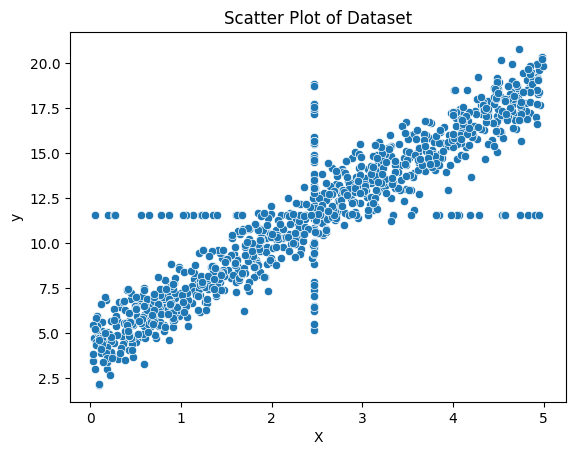

In [ ]:

sns.scatterplot(x=df["X"], y=df["y"])
plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter Plot of Dataset")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(df[["X"]], df["y"], test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

initial_m = model.coef_[0]

# Make predictions
y_pred = model.predict(X_test)


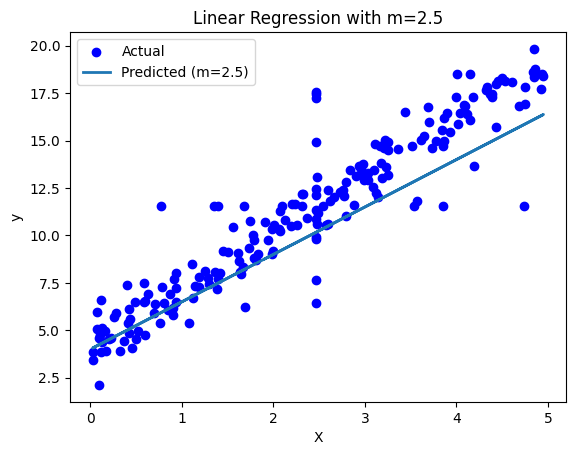

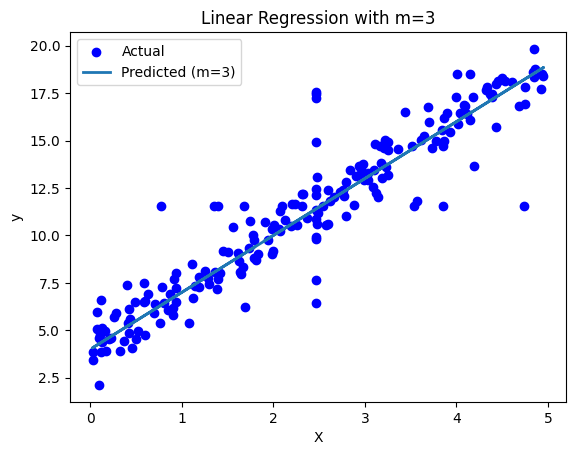

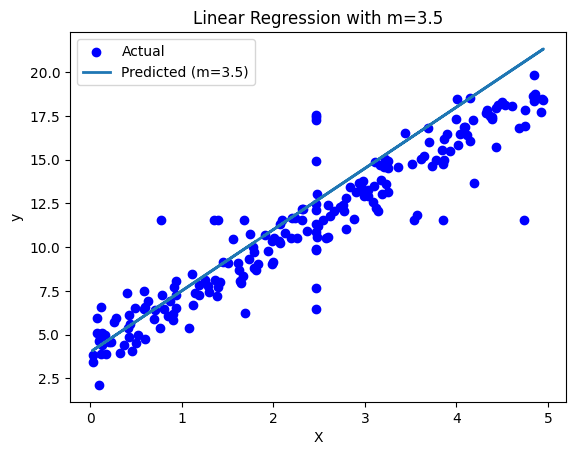

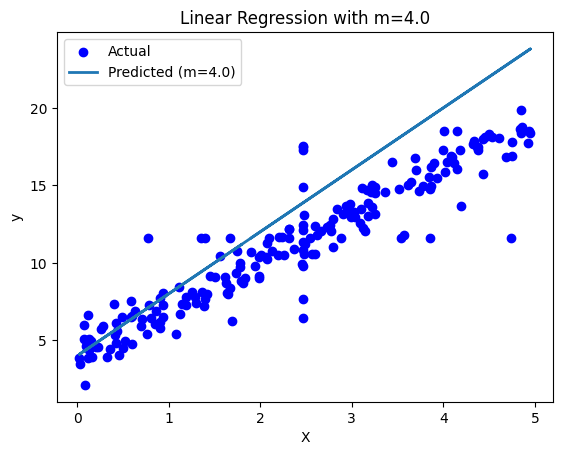

Initial Model (m=2.7860) - MSE: 2.2310, R²: 0.8814, MAE: 1.0078
Alternative Model (m=2.5) - MSE: 4.2982, R²: 0.7716, MAE: 1.6317
Alternative Model (m=3) - MSE: 2.2543, R²: 0.8802, MAE: 0.9782
Alternative Model (m=3.5) - MSE: 3.9216, R²: 0.7916, MAE: 1.4918
Alternative Model (m=4.0) - MSE: 9.3001, R²: 0.5058, MAE: 2.5059


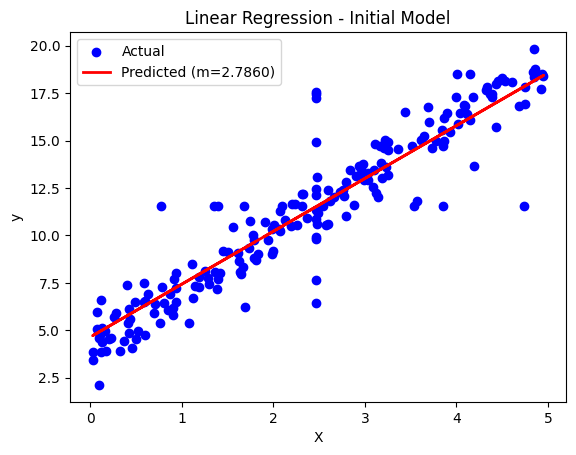

In [ ]:

# Compute performance metrics for initial model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Try different slopes (m values) to check for best fit
alternative_m_values = [2.5, 3,3.5, 4.0]
performance_metrics = []

for m in alternative_m_values:
    y_alt = 4 + m * X_test  # Different slopes
    mse_alt = mean_squared_error(y_test, y_alt)
    r2_alt = r2_score(y_test, y_alt)
    mae_alt = mean_absolute_error(y_test, y_alt)
    performance_metrics.append((m, mse_alt, r2_alt, mae_alt))

    # Plot for each alternative model
    plt.scatter(X_test, y_test, color="blue", label="Actual")
    plt.plot(X_test, y_alt, linewidth=2, label=f"Predicted (m={m})")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title(f"Linear Regression with m={m}")
    plt.legend()
    plt.show()

# Print performance metrics for each model
print(f"Initial Model (m={initial_m:.4f}) - MSE: {mse:.4f}, R²: {r2:.4f}, MAE: {mae:.4f}")
for m, mse_alt, r2_alt, mae_alt in performance_metrics:
    print(f"Alternative Model (m={m}) - MSE: {mse_alt:.4f}, R²: {r2_alt:.4f}, MAE: {mae_alt:.4f}")

# Plot the results for the initial model
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label=f"Predicted (m={initial_m:.4f})")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression - Initial Model")
plt.legend()
plt.show()